In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [10]:
df.sample(10)

,Class label,Alcohol,Malic acid
13,1,14.75,1.73
114,2,12.08,1.39
142,3,13.52,3.17
177,3,14.13,4.10
169,3,13.40,4.60
150,3,13.50,3.12
49,1,13.94,1.73
81,2,12.72,1.81
137,3,12.53,5.51
95,2,12.47,1.52


<Axes: xlabel='Alcohol', ylabel='Density'>

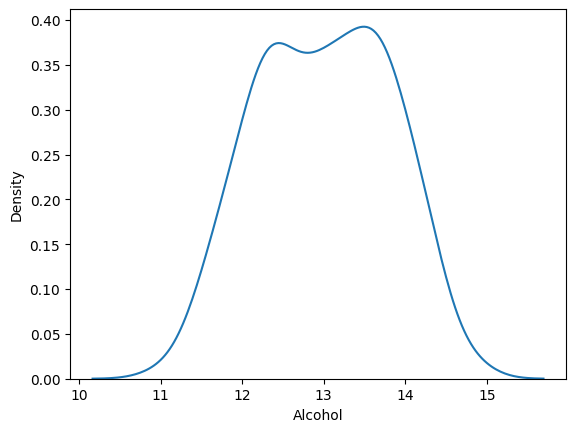

In [12]:
sns.kdeplot(df["Alcohol"])

<Axes: xlabel='Malic acid', ylabel='Density'>

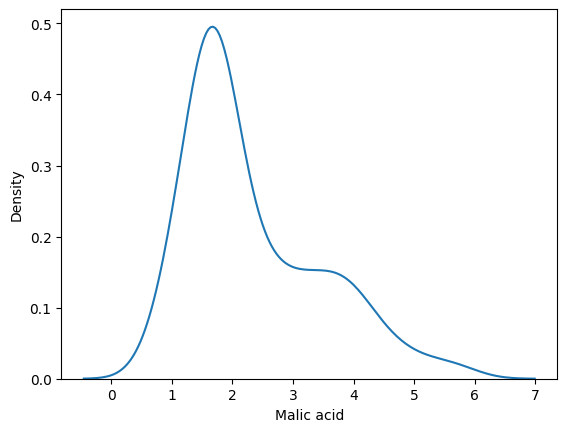

In [14]:
sns.kdeplot(df["Malic acid"])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

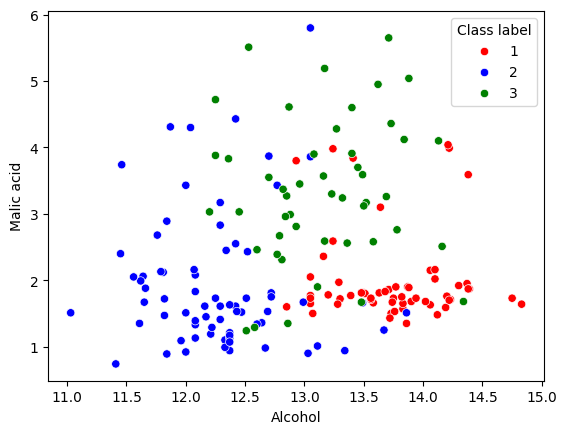

In [20]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],
                hue=df['Class label'],
                palette=color_dict)

In [34]:
# doing the train_test_split
from sklearn.model_selection import train_test_split


In [36]:
x_train,x_test ,y_train,y_test = train_test_split( df.drop('Class label',axis=1),
                                                  df['Class label'],
                                                  test_size = 0.3,
                                                  random_state = 0 )
                                                   


In [38]:
x_train.shape ,x_test.shape

((124, 2), (54, 2))

<h5>Now  we will perform the normalization (MinMaxScaling)</h5>

In [41]:
from sklearn.preprocessing import MinMaxScaler

In [43]:
scaler = MinMaxScaler() # we have created an object of MinMax class 

In [47]:
# fitting the scaler with train set so that it will run the parameter 
scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [49]:
# now transforming tuhe train and test data 

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [51]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [55]:
x_train_scaled.head()

,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252


In [59]:
np.round(x_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [61]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'After_Scaling')

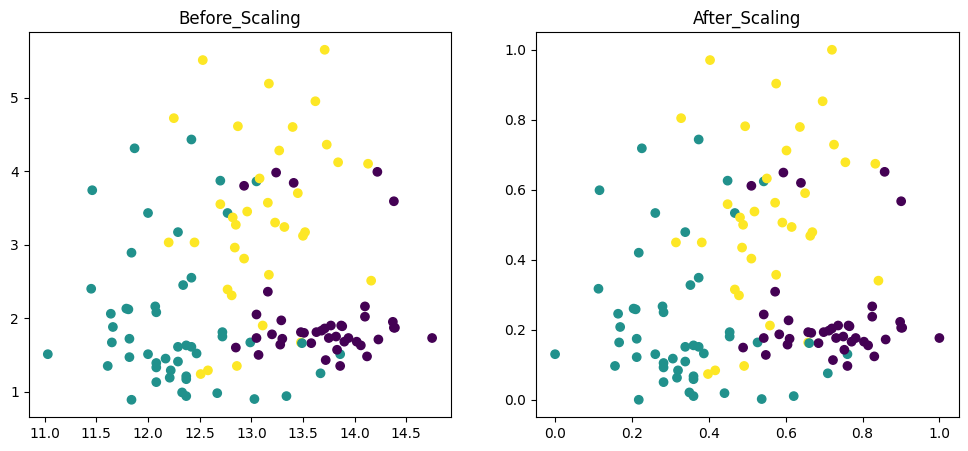

In [68]:
fig ,(ax1,ax2) =plt.subplots(ncols = 2 , figsize =(12,5))

ax1.scatter(x_train['Alcohol'],x_train['Malic acid'],c=y_train)
ax1.set_title("Before_Scaling")

ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After_Scaling")

<h2>Comparing the range of both column before and after Scaling</h2>

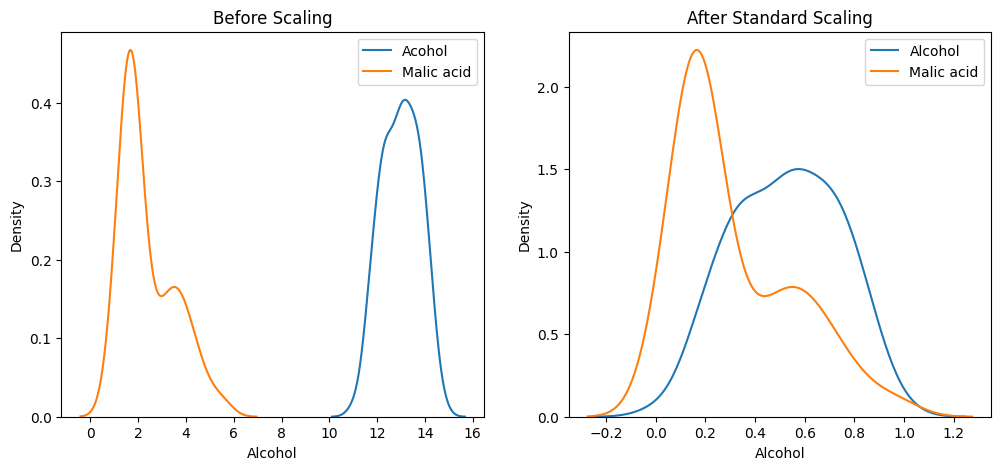

In [80]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1 ,label="Acohol")
sns.kdeplot(x_train['Malic acid'], ax=ax1 ,label = "Malic acid")
ax1.legend()
# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2,label="Alcohol")
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2 ,label = "Malic acid")
ax2.legend()

<h3>Now seeing the individual distributio Before and after Scaling</h3>

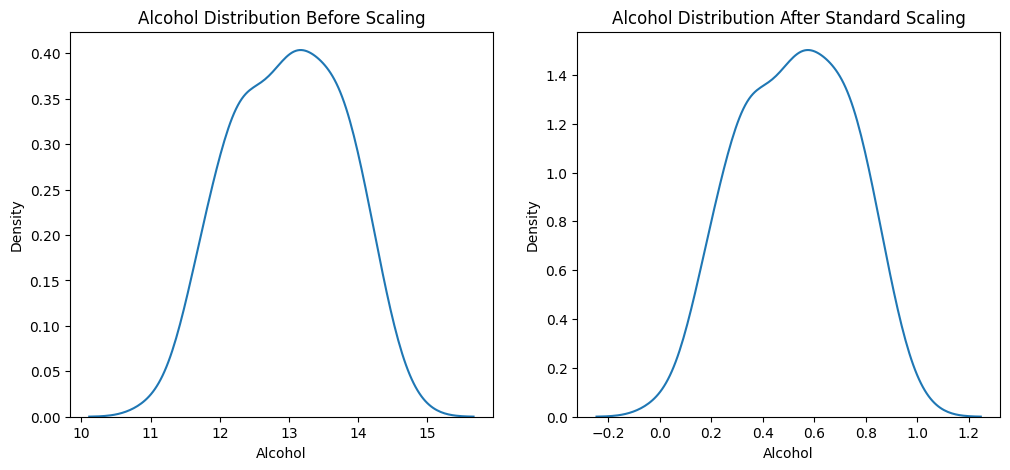

In [85]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
plt.show()

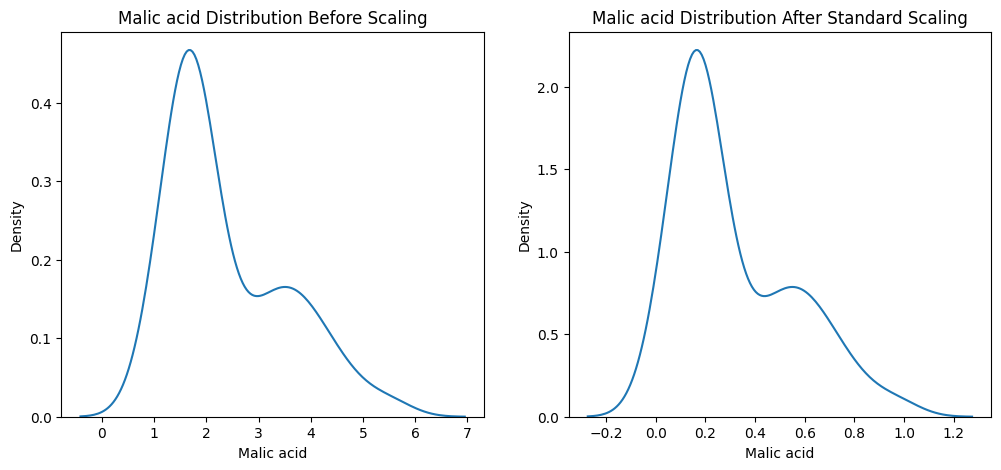

In [87]:
ig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(x_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()